In [23]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sns.set_style('whitegrid')
%matplotlib inline

In [24]:
from google.colab import files
uploaded  = files.upload()

Saving cricket_data_2026.csv to cricket_data_2026 (1).csv


In [25]:
df = pd.read_csv('cricket_data_2026.csv')
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (1096, 25)

First 5 rows:


,Player_Name,Year,Matches_Batted,Not_Outs,Runs_Scored,Highest_Score,Batting_Average,Balls_Faced,Batting_Strike_Rate,Centuries,...,Matches_Bowled,Balls_Bowled,Runs_Conceded,Wickets_Taken,Best_Bowling_Match,Bowling_Average,Economy_Rate,Bowling_Strike_Rate,Four_Wicket_Hauls,Five_Wicket_Hauls
0,Abdul Samad,2025,13,4,164,45,20.5,93,176.34,0,...,13,2,6,0,0/6,0,18.00,0,0,0
1,Abdul Samad,2024,16,2,182,37*,18.2,108,168.52,0,...,16,0,0,0,0,0,0,0,0,0
2,Abdul Samad,2023,9,4,169,37*,42.25,128,132.03,0,...,9,0,0,0,0,0,0,0,0,0
3,Abdul Samad,2022,2,0,4,4,2.0,7,57.14,0,...,2,6,8,0,0/8,0,8.00,0,0,0
4,Abdul Samad,2021,11,1,111,28,12.33,87,127.58,0,...,11,6,9,1,1/9,9.00,9.00,6.00,0,0


In [26]:
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print(f"\nUnique Players: {df['Player_Name'].nunique()}")
print(f"Years Range: {df['Year'].min()} to {df['Year'].max()}")

Data Types:
Player_Name            object
Year                   object
Matches_Batted         object
Not_Outs               object
Runs_Scored            object
Highest_Score          object
Batting_Average        object
Balls_Faced            object
Batting_Strike_Rate    object
Centuries              object
Half_Centuries         object
Fours                  object
Sixes                  object
Catches_Taken          object
Stumpings              object
Matches_Bowled         object
Balls_Bowled           object
Runs_Conceded          object
Wickets_Taken          object
Best_Bowling_Match     object
Bowling_Average        object
Economy_Rate           object
Bowling_Strike_Rate    object
Four_Wicket_Hauls      object
Five_Wicket_Hauls      object
dtype: object

Missing Values:
Player_Name            0
Year                   0
Matches_Batted         0
Not_Outs               0
Runs_Scored            0
Highest_Score          0
Batting_Average        0
Balls_Faced            0
Batting

In [27]:
df_clean = df[df['Matches_Batted'] != 'No stats'].copy()
df_clean = df_clean[df_clean['Matches_Batted'] != '0'].copy()

numeric_cols = ['Matches_Batted', 'Not_Outs', 'Runs_Scored', 'Highest_Score',
                'Batting_Average', 'Balls_Faced', 'Batting_Strike_Rate',
                'Centuries', 'Half_Centuries', 'Fours', 'Sixes',
                'Catches_Taken', 'Stumpings']

for col in numeric_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')


df_clean = df_clean.dropna(subset=['Batting_Average'])
df_clean = df_clean[df_clean['Batting_Average'] > 0]

print(f"After cleaning: {len(df_clean)} rows")

After cleaning: 785 rows


In [28]:
df_clean['Dismissals'] = df_clean['Matches_Batted'] - df_clean['Not_Outs']

df_clean['Boundary_Percentage'] = ((df_clean['Fours']*4 + df_clean['Sixes']*6) / df_clean['Runs_Scored'] * 100).replace([np.inf, -np.inf], 0).fillna(0)

df_clean['Strike_Rate_Category'] = pd.cut(df_clean['Batting_Strike_Rate'],
                                           bins=[0, 120, 140, 200],
                                           labels=['Low', 'Medium', 'High'])

print("Feature engineering complete!")

Feature engineering complete!


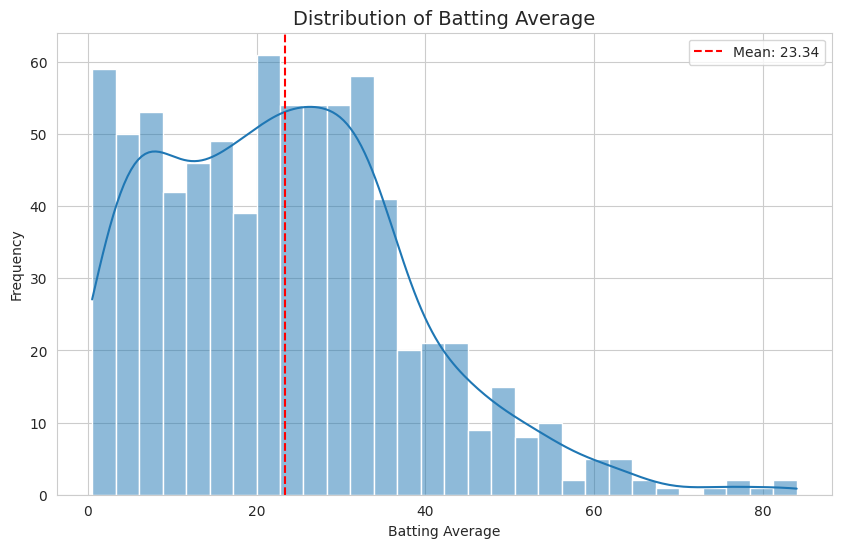

In [29]:
plt.figure(figsize=(10,6))
sns.histplot(df_clean['Batting_Average'], bins=30, kde=True)
plt.title('Distribution of Batting Average', fontsize=14)
plt.xlabel('Batting Average')
plt.ylabel('Frequency')
plt.axvline(df_clean['Batting_Average'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["Batting_Average"].mean():.2f}')
plt.legend()
plt.show()

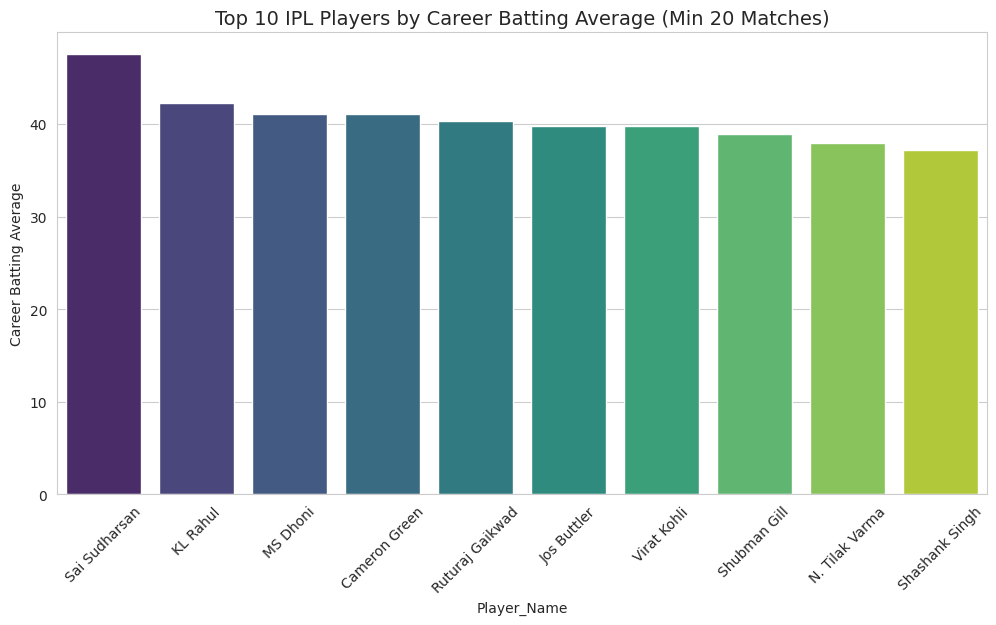

In [30]:
player_stats = df_clean.groupby('Player_Name').agg({
    'Batting_Average': 'mean',
    'Matches_Batted': 'sum',
    'Runs_Scored': 'sum'
}).reset_index()

top_players = player_stats[player_stats['Matches_Batted'] >= 20].sort_values('Batting_Average', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=top_players, x='Player_Name', y='Batting_Average', palette='viridis')
plt.title('Top 10 IPL Players by Career Batting Average (Min 20 Matches)', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Career Batting Average')
plt.show()

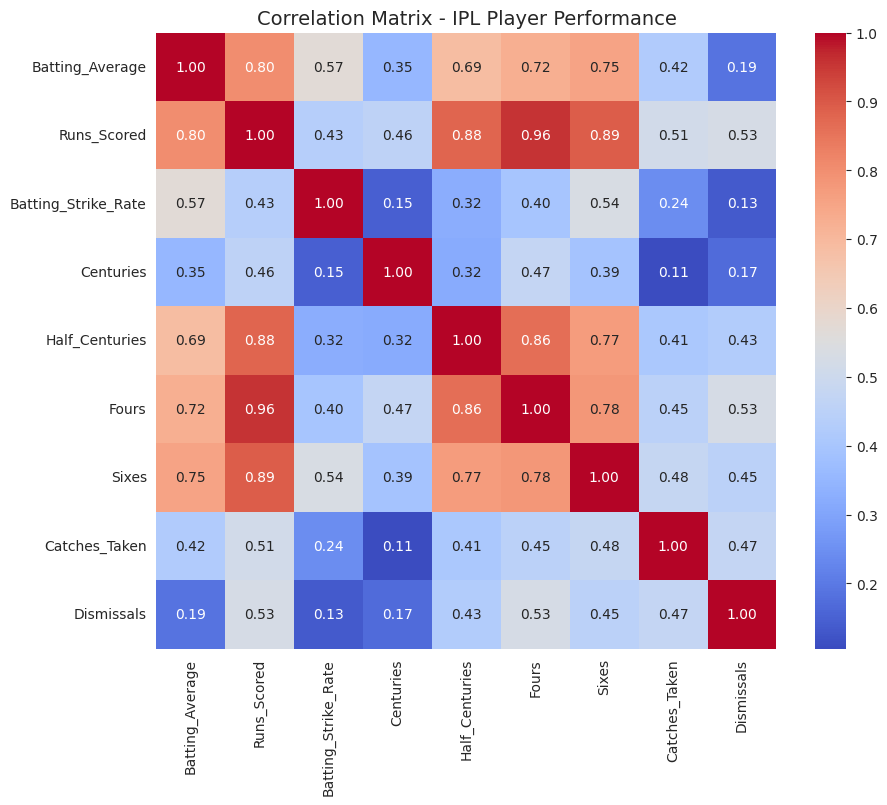

In [31]:

selected_features = ['Batting_Average', 'Runs_Scored', 'Batting_Strike_Rate',
                     'Centuries', 'Half_Centuries', 'Fours', 'Sixes',
                     'Catches_Taken', 'Dismissals']

plt.figure(figsize=(10,8))
sns.heatmap(df_clean[selected_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix - IPL Player Performance', fontsize=14)
plt.show()

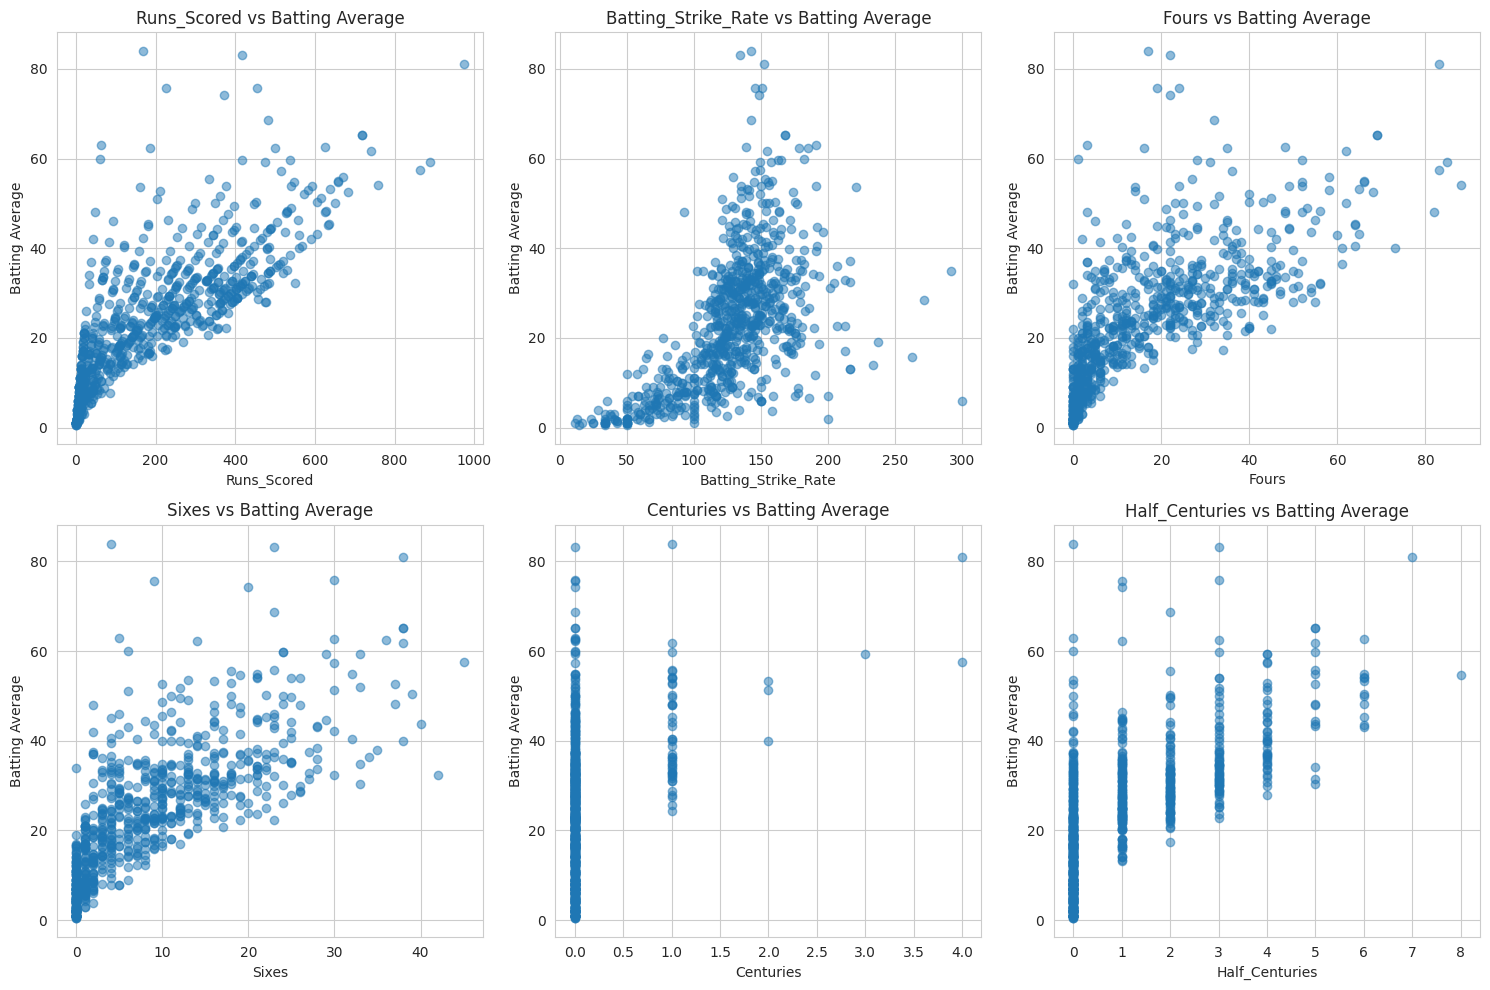

In [32]:

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = ['Runs_Scored', 'Batting_Strike_Rate', 'Fours', 'Sixes', 'Centuries', 'Half_Centuries']

for idx, feature in enumerate(features):
    row, col = idx // 3, idx % 3
    axes[row, col].scatter(df_clean[feature], df_clean['Batting_Average'], alpha=0.5)
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Batting Average')
    axes[row, col].set_title(f'{feature} vs Batting Average')

plt.tight_layout()
plt.show()

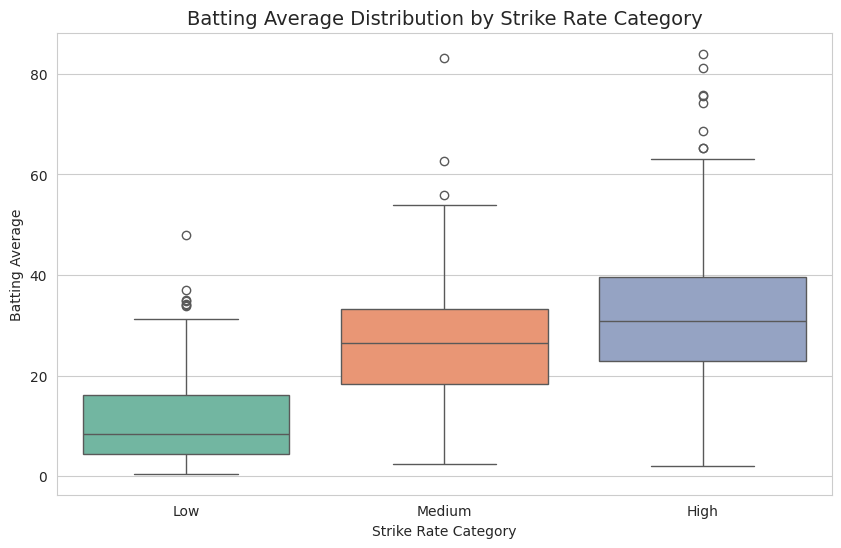

In [33]:

plt.figure(figsize=(10,6))
sns.boxplot(data=df_clean, x='Strike_Rate_Category', y='Batting_Average', palette='Set2')
plt.title('Batting Average Distribution by Strike Rate Category', fontsize=14)
plt.xlabel('Strike Rate Category')
plt.ylabel('Batting Average')
plt.show()

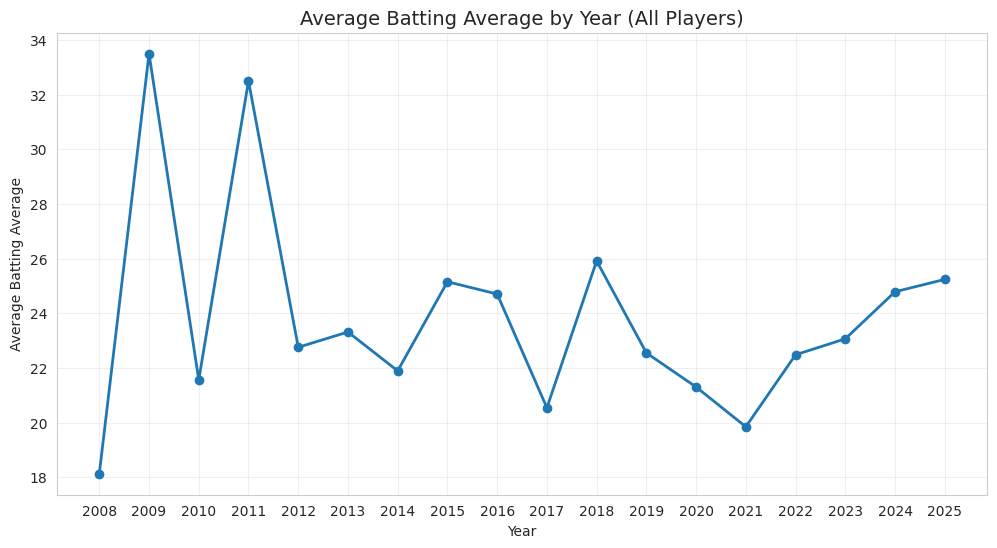

In [34]:

yearly_avg = df_clean.groupby('Year')['Batting_Average'].mean().reset_index()

plt.figure(figsize=(12,6))
plt.plot(yearly_avg['Year'], yearly_avg['Batting_Average'], marker='o', linewidth=2)
plt.title('Average Batting Average by Year (All Players)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Batting Average')
plt.grid(True, alpha=0.3)
plt.show()

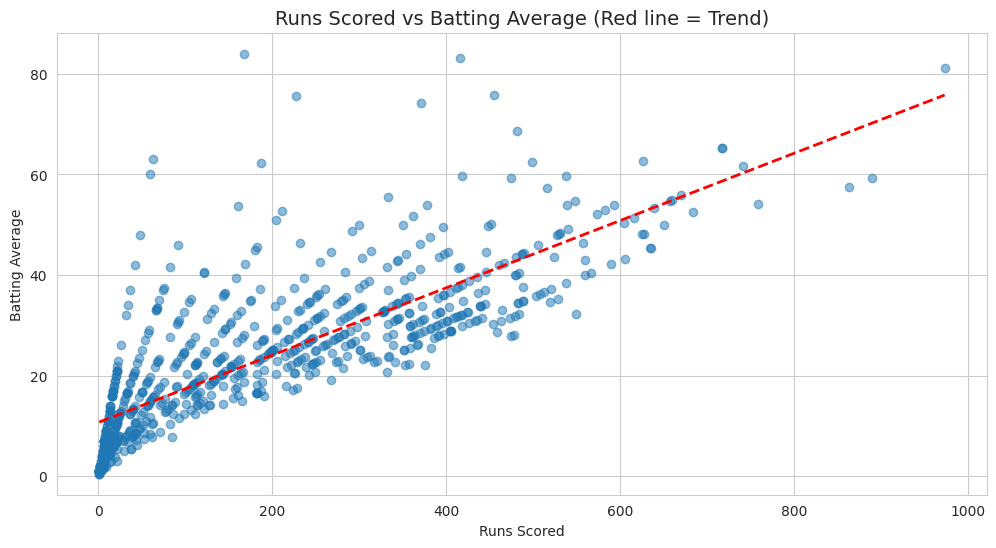

In [35]:

plt.figure(figsize=(12,6))
plt.scatter(df_clean['Runs_Scored'], df_clean['Batting_Average'], alpha=0.5)

z = np.polyfit(df_clean['Runs_Scored'], df_clean['Batting_Average'], 1)
p = np.poly1d(z)
plt.plot(df_clean['Runs_Scored'].sort_values(), p(df_clean['Runs_Scored'].sort_values()), "r--", linewidth=2)

plt.xlabel('Runs Scored')
plt.ylabel('Batting Average')
plt.title('Runs Scored vs Batting Average (Red line = Trend)', fontsize=14)
plt.show()

In [36]:

feature_cols = ['Runs_Scored', 'Batting_Strike_Rate', 'Centuries',
                'Half_Centuries', 'Fours', 'Sixes', 'Catches_Taken',
                'Stumpings', 'Dismissals']

X = df_clean[feature_cols]
y = df_clean['Batting_Average']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (785, 9)
Target shape: (785,)


In [37]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols)

print(f"Training set: {X_train_scaled.shape[0]} samples")
print(f"Test set: {X_test_scaled.shape[0]} samples")

Training set: 628 samples
Test set: 157 samples


In [38]:

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

print("Model trained successfully!")

Model trained successfully!


In [39]:

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"R² Score: {r2:.4f}  (Explains {r2*100:.1f}% of variance)")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print("="*50)

if r2 > 0.8:
    print(" Excellent fit - Model captures most patterns well")
elif r2 > 0.6:
    print(" Good fit - Model captures many patterns")
elif r2 > 0.4:
    print(" Moderate fit - Some patterns captured")
else:
    print(" Weak fit - Try different features or models")

MODEL PERFORMANCE METRICS
R² Score: 0.7461  (Explains 74.6% of variance)
Mean Squared Error (MSE): 59.80
Root Mean Squared Error (RMSE): 7.73
Mean Absolute Error (MAE): 5.22
Mean Absolute Percentage Error (MAPE): 49.51%
 Good fit - Model captures many patterns


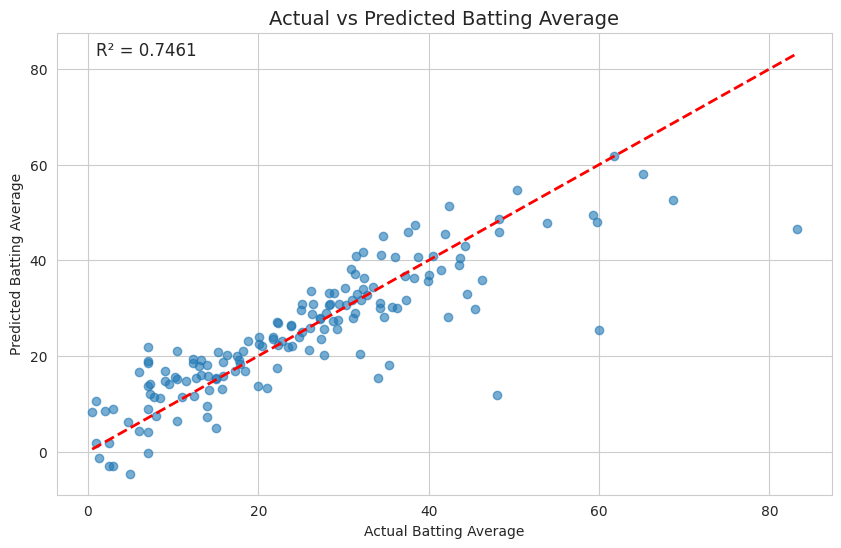

In [40]:

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Batting Average')
plt.ylabel('Predicted Batting Average')
plt.title('Actual vs Predicted Batting Average', fontsize=14)
plt.text(0.05, 0.95, f'R² = {r2:.4f}', transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(facecolor='white', alpha=0.8))
plt.show()

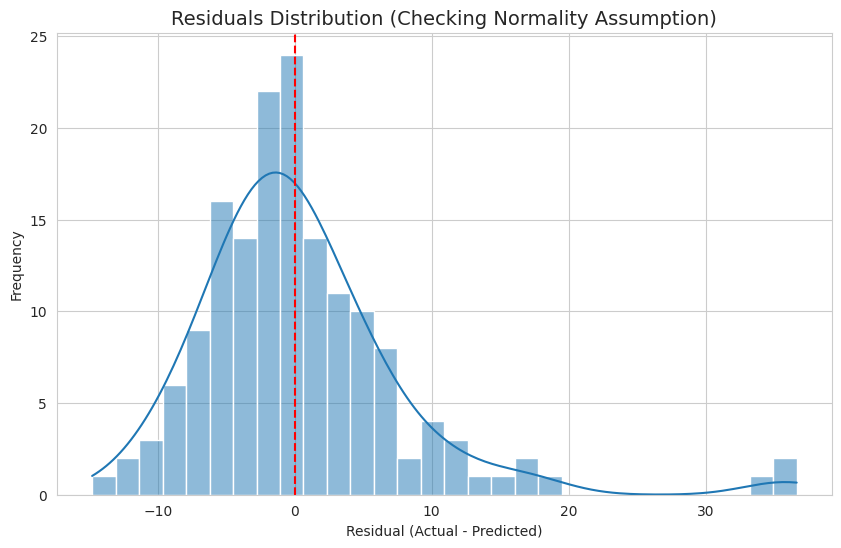

Mean of residuals: 0.3448
Std of residuals: 7.7500


In [41]:

residuals = y_test - y_pred

plt.figure(figsize=(10,6))
sns.histplot(residuals, kde=True, bins=30)
plt.title('Residuals Distribution (Checking Normality Assumption)', fontsize=14)
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--')
plt.show()

print(f"Mean of residuals: {residuals.mean():.4f}")
print(f"Std of residuals: {residuals.std():.4f}")

In [42]:

coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr.coef_
}).sort_values(by='Coefficient', ascending=False)

print("="*50)
print("FEATURE IMPORTANCE (Coefficients)")
print("="*50)
print(coef_df)

print("\n" + "="*50)
print("INTERPRETATION")
print("="*50)
print(f" Most Important (Positive): {coef_df.iloc[0]['Feature']}")
print(f"   → Increases Batting Average by {coef_df.iloc[0]['Coefficient']:.2f} per unit increase")
print(f"\n Least Important (Negative): {coef_df.iloc[-1]['Feature']}")
print(f"   → Decreases Batting Average by {abs(coef_df.iloc[-1]['Coefficient']):.2f} per unit increase")

FEATURE IMPORTANCE (Coefficients)
               Feature  Coefficient
0          Runs_Scored    22.917036
1  Batting_Strike_Rate     4.123253
6        Catches_Taken     0.683212
2            Centuries    -0.121214
7            Stumpings    -0.158276
3       Half_Centuries    -0.319261
5                Sixes    -3.043455
8           Dismissals    -4.448012
4                Fours    -7.895481

INTERPRETATION
 Most Important (Positive): Runs_Scored
   → Increases Batting Average by 22.92 per unit increase

 Least Important (Negative): Fours
   → Decreases Batting Average by 7.90 per unit increase


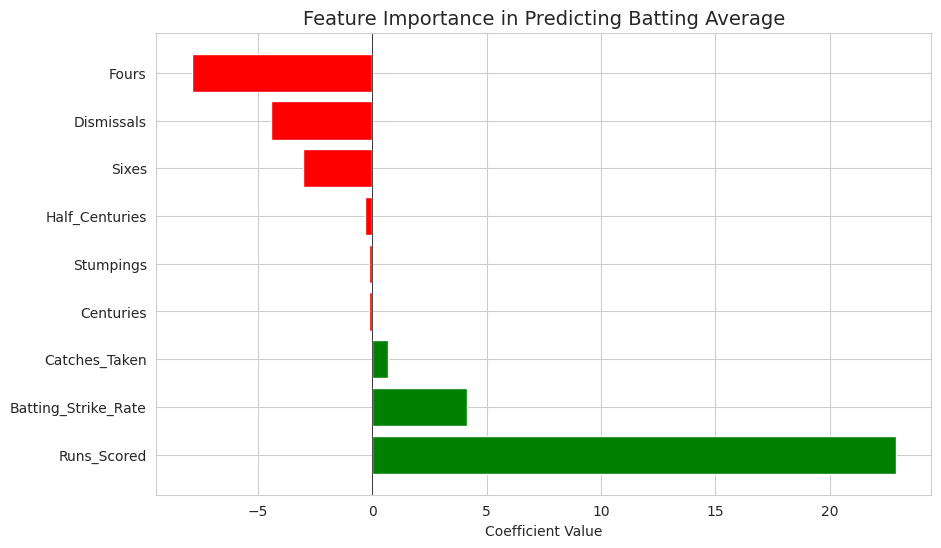

In [43]:

plt.figure(figsize=(10,6))
colors = ['green' if x > 0 else 'red' for x in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Predicting Batting Average', fontsize=14)
plt.show()

In [44]:

sample_data = [[500, 140, 1, 3, 30, 20, 10, 2, 8]]
sample_scaled = scaler.transform(sample_data)
predicted_avg = lr.predict(sample_scaled)[0]

print("="*50)
print("PREDICTION FOR NEW PLAYER")
print("="*50)
print(f"Input Features: Runs=500, SR=140, 1 Century, 3 Half-Centuries, 30 Fours, 20 Sixes, 10 Catches, 2 Stumpings, 8 Dismissals")
print(f"Predicted Batting Average: {predicted_avg:.2f}")

PREDICTION FOR NEW PLAYER
Input Features: Runs=500, SR=140, 1 Century, 3 Half-Centuries, 30 Fours, 20 Sixes, 10 Catches, 2 Stumpings, 8 Dismissals
Predicted Batting Average: 55.32
